# Q1 · Radar budget (deliverable D1.3)

Live numbers computed from [`params/variables.yaml`](../../params/variables.yaml).

- **Change design values in the register, not in this notebook.** Then re-run all cells.
- Every row cites its equation in [`docs/equations.md`](../../docs/equations.md).
- ✅ passes a requirement · ❌ fails one · ⏳ needs an input that is still TBD.

Open in Colab: colab.research.google.com → File → Open notebook → GitHub tab → paste the repo URL.

In [1]:
# Setup — run this first. Finds the repo on your computer; in Google Colab it asks
# which GitHub repo to load and clones it.
import sys, pathlib, subprocess

def _find_repo():
    for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (d / "params" / "variables.yaml").exists():
            return d
    return None

ROOT = _find_repo()
if ROOT is None and "google.colab" in sys.modules:
    repo = input("GitHub repo to load (owner/name): ").strip()
    subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{repo}.git", "/content/repo"], check=True)
    ROOT = pathlib.Path("/content/repo")
if ROOT is None:
    raise RuntimeError("Open this notebook from inside the repo folder, or in Google Colab.")
sys.path.insert(0, str(ROOT))
print("Repo found ✓")

Repo found ✓


In [2]:
from hs3gpr.params import load
from hs3gpr import budget

p = load()
rows = budget.compute(p)
budget.show(rows)

**Checks:** ✅ 6 pass · ❌ 0 fail · ⏳ 5 need an input that is still TBD

## Timing

| Quantity | Value | Unit | Equation | Check |
|---|---:|---|---|---|
| Wavelength λ | 15.0 | m | λ = c/f0 |  |
| Surface echo delay, lowest altitude | 200 | µs | EQ-01 |  |
| Surface echo delay, nominal altitude | 334 | µs | EQ-01 |  |
| Surface echo delay, highest altitude | 667 | µs | EQ-01 |  |
| Extra delay to the deepest roof (basalt) | 8.83 | µs | EQ-01 |  |
| Window length needed (margin + deepest roof) | 13.8 | µs | EQ-01 | ✅ limit 40.0 µs |
| Time available for the chirp at lowest altitude | 190 | µs | EQ-14 | ✅ chirp is 50.0 µs |
| Duty cycle | 5.00 | % | EQ-14 |  |
| Receive window vs transmit pulses | clear at all altitudes |  | EQ-14 | ✅ |

## Resolution & footprint

| Quantity | Value | Unit | Equation | Check |
|---|---:|---|---|---|
| Vertical resolution, free space | 15.0 | m | EQ-03 |  |
| Vertical resolution, regolith | 9.12 | m | EQ-03 |  |
| Vertical resolution, basalt | 5.67 | m | EQ-03 | ⏳ to check, set vertical_resolution_req |
| Fresnel zone diameter (nominal altitude) | 1,224 | m | EQ-09 |  |
| Pulse-limited footprint (nominal altitude) | 2,449 | m | EQ-09 |  |
| Synthetic aperture length for δx_req | 1,499 | m | EQ-09 |  |
| Orbital period (nominal altitude) | 113 | min | EQ-13 |  |
| Ground speed (nominal altitude) | 1,610 | m/s | EQ-13 |  |
| Spacing between presummed traces | 25.8 | m | EQ-10 | ✅ limit 250 m |
| Traces combined by SAR, M | 58 | - | EQ-09 |  |
| SAR aperture time | 0.93 | s | EQ-09 | the clock must stay coherent this long; see clock_stability |

## Propagation

| Quantity | Value | Unit | Equation | Check |
|---|---:|---|---|---|
| Wave speed in regolith | 0.61 | × c | c/√εr |  |
| Wave speed in basalt | 0.38 | × c | c/√εr |  |
| Attenuation in regolith (one way) | 0.015 | dB/m | EQ-04 |  |
| Attenuation in basalt (one way) | 0.0482 | dB/m | EQ-04 |  |
| Two-way attenuation to the deepest roof | 47.8 | dB | EQ-04 |  |
| Surface reflection (vacuum → regolith) | -12.3 | dB | EQ-05 |  |
| Layer reflection (regolith → basalt) | -12.6 | dB | EQ-05 |  |
| Roof reflection (basalt → void) | -6.91 | dB | EQ-05 |  |

## Noise & SNR

| Quantity | Value | Unit | Equation | Check |
|---|---:|---|---|---|
| Galactic noise temperature at f0 | 46,777 | K | EQ-07 |  |
| System noise temperature | 33,119 | K | EQ-07 |  |
| Surface echo SNR, one pulse (compressed) | 40.8 | dB | EQ-06, EQ-08 |  |
| Deepest roof SNR, one pulse (compressed) | -2.67 | dB | EQ-06, EQ-08 |  |
| Gain: pulse compression T·B | 27.0 | dB | EQ-08 | already included in the one-pulse rows |
| Gain: presumming N | 12.0 | dB | EQ-08 |  |
| Gain: SAR M | 17.6 | dB | EQ-08 |  |
| Other losses | -3 | dB |  |  |
| Deepest roof SNR after processing | 24.0 | dB | EQ-08 | ✅ margin 14.0 dB |
| Deepest roof that meets SNR_req | 645 | m | EQ-08 | ✅ margin 145 m |
| Surface-to-roof echo ratio (one pulse) | 43.5 | dB |  | surface-echo sidelobes and ADC dynamic range must cope with this |

## Data & downlink

| Quantity | Value | Unit | Equation | Check |
|---|---:|---|---|---|
| Samples per trace | 2,000 | - |  |  |
| Raw data rate (no presum) | 24.0 | Mbit/s | EQ-11 |  |
| Data rate after presum + requantization | 1.00 | Mbit/s | EQ-11 |  |
| Radar data per day | 225 | MB | EQ-11 |  |
| Downlink rate needed to clear a day's data | 125 | kbit/s | EQ-11 | ⏳ to check, set downlink_rate |
| Memory needed for one day of data | 225 | MB |  | ⏳ to check, set mass_memory |
| Path loss Moon → Earth at f_dl | 223 | dB | EQ-12 |  |
| Extra path loss vs a 500 km LEO link | 57.7 | dB | EQ-12 |  |

## Power

| Quantity | Value | Unit | Equation | Check |
|---|---:|---|---|---|
| Peak DC power during a pulse | 30.0 | W | EQ-15 | ⏳ to check, set payload_power_peak |
| Average power while observing | 6.25 | W | EQ-15 |  |
| Radar power averaged over a day | 0.13 | W | EQ-15 | ⏳ to check, set payload_power_orbit_avg |
| Energy per day | 3.12 | Wh | EQ-15 |  |
| Energy drawn per pulse | 1.25 | mJ | EQ-15 | sizes the capacitor bank |


## What-if: try another design point without editing the file

`with_values` makes a copy with some values changed. Here: a 5 MHz radar with a 30 m dipole.

In [3]:
q = p.with_values(f_center=5e6, bandwidth=2e6, antenna_length=30.0)
budget.show(budget.compute(q), groups=["Noise & SNR"])

**Checks:** ✅ 2 pass · ❌ 0 fail · ⏳ 0 need an input that is still TBD

## Noise & SNR

| Quantity | Value | Unit | Equation | Check |
|---|---:|---|---|---|
| Galactic noise temperature at f0 | 1,134,402 | K | EQ-07 |  |
| System noise temperature | 794,457 | K | EQ-07 |  |
| Surface echo SNR, one pulse (compressed) | 39.1 | dB | EQ-06, EQ-08 |  |
| Deepest roof SNR, one pulse (compressed) | 31.4 | dB | EQ-06, EQ-08 |  |
| Gain: pulse compression T·B | 20.0 | dB | EQ-08 | already included in the one-pulse rows |
| Gain: presumming N | 12.0 | dB | EQ-08 |  |
| Gain: SAR M | 23.7 | dB | EQ-08 |  |
| Other losses | -3 | dB |  |  |
| Deepest roof SNR after processing | 64.1 | dB | EQ-08 | ✅ margin 54.1 dB |
| Deepest roof that meets SNR_req | 2,742 | m | EQ-08 | ✅ margin 2,242 m |
| Surface-to-roof echo ratio (one pulse) | 7.64 | dB |  | surface-echo sidelobes and ADC dynamic range must cope with this |


## How deep can we see?

Final SNR of a lava-tube roof versus depth, for each basalt loss tangent in `tan_delta_sweep`. The loss tangent is the biggest unknown, so this plot is the first thing to update when the scene team finds better sources.

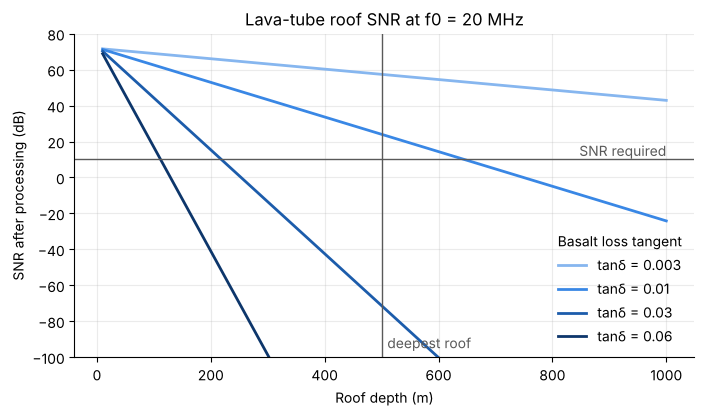

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.2), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
RAMP = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]   # one blue, light → dark, for ordered values
import numpy as np

depths = np.linspace(10, 1000, 200)
fig, ax = plt.subplots()
for color, tan_d in zip(RAMP, p["tan_delta_sweep"]):
    snr = budget.snr_vs_depth(p.with_values(tan_delta_basalt=tan_d), depths)
    ax.plot(depths, snr, color=color, lw=2, label=f"tanδ = {tan_d:g}")
ax.axhline(p["snr_required"], color="0.35", lw=1)
ax.text(1000, p["snr_required"] + 2, "SNR required", ha="right", color="0.35")
ax.axvline(p["roof_depth_max"], color="0.35", lw=1)
ax.text(p["roof_depth_max"] + 10, -95, "deepest roof", color="0.35")
ax.set(xlabel="Roof depth (m)", ylabel="SNR after processing (dB)", ylim=(-100, 80),
       title=f"Lava-tube roof SNR at f0 = {p['f_center']/1e6:g} MHz")
ax.legend(title="Basalt loss tangent", frameon=False)
plt.show()

**Next:** record what you learned in [`q1-baseline/2-trades/TS-1-frequency-bandwidth.md`](../2-trades/TS-1-frequency-bandwidth.md), and update `status`/`source` for any variable you pinned down.